# **🔐 Deep Content-Driven Image Encryption using CNN–ViT Fusion and Multi-Chaotic Systems**
📌 **Overview**
This project proposes a high-security image encryption framework based on a hybrid deep learning architecture combined with multi-chaotic dynamics.

The system generates content-dependent **cryptographic** keys using a fusion of:

🔹 Convolutional Neural Networks (CNN).
🔹 Vision Transformers (ViT).
🔹 Attention mechanisms.

These keys are then used to drive chaotic maps for robust image encryption and decryption.

🧠 **Key Features**:
🔹 Content-driven key generation
🔹 CNN + Vision Transformer fusion
🔹 Multi-head attention mechanism
🔹 Adaptive chaotic map selection
🔹 Permutation + diffusion encryption scheme
🔹 Entropy-based security evaluation
🏗️ Architecture
1️⃣ AdvancedLKM (Learning Key Model)

A hybrid deep learning model that extracts robust image features:

🔹 ResNet18 (CNN) → local feature extraction
🔹 ViT-B/16 (Transformer) → global context modeling
🔹 Feature fusion via Multi-Head Attention
🔹 Fully connected layers → generate a high-dimensional key

👉 Output: Content-dependent encryption key

2️⃣ **Multi-Chaotic Maps**

The system integrates several chaotic generators:

🔹 Logistic Map
🔹 Tent Map
🔹 Sine Map
🔹 Henon Map
🔹 Chebyshev Map

✔ A dynamic selector chooses the chaotic system based on the generated key.

3️⃣ **Key Generation Strategy**:

🔹 The deep key is converted into a scalar seed
🔹 A chaotic map is selected deterministically
🔹 A pseudo-random sequence is generated
🔹 The sequence is converted into a byte-level encryption key.

4️⃣ **Encryption Process**

The encryption consists of two main steps:

🔀 Permutation : Pixel positions are shuffled using a chaotic permutation
🔐 Diffusion : XOR operation between pixels and chaotic key
5️⃣ Decryption Process
🔹 XOR reversal
🔹 Inverse permutation
🔹 Reconstruction of the original image
✔ Fully deterministic and lossless

6️⃣ **Security Metric**
Shannon Entropy is computed to evaluate randomness:
🔹 Ideal value ≈ 8 for 8-bit images
**Higher entropy → stronger encryption**

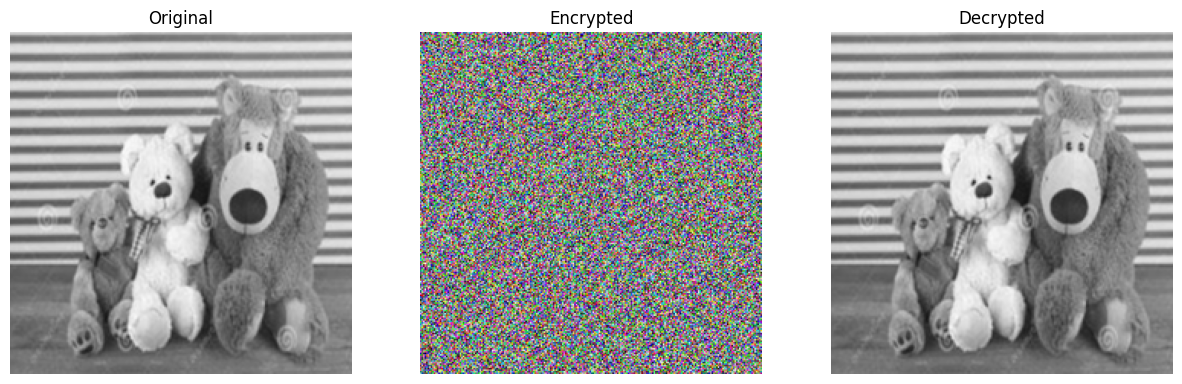

Entropy: 7.976286678172417


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18, vit_b_16
from PIL import Image
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# 1️⃣ Advanced LKM (CNN + ViT + Attention)
# ==========================================================

class AdvancedLKM(nn.Module):
    def __init__(self, key_dim=512):
        super().__init__()

        self.cnn = resnet18(weights="IMAGENET1K_V1")
        self.cnn.fc = nn.Identity()

        self.vit = vit_b_16(weights="IMAGENET1K_V1")
        self.vit.heads = nn.Identity()

        self.cnn_proj = nn.Linear(512, 768)

        self.attention = nn.MultiheadAttention(
            embed_dim=768,
            num_heads=8,
            batch_first=True
        )

        self.key_generator = nn.Sequential(
            nn.Linear(768, 1024),
            nn.ReLU(),
            nn.Linear(1024, key_dim)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        vit_feat = self.vit(x)

        cnn_feat = self.cnn_proj(cnn_feat)

        fused = torch.stack([cnn_feat, vit_feat], dim=1)
        attn_output, _ = self.attention(fused, fused, fused)

        fused_vector = torch.mean(attn_output, dim=1)

        return self.key_generator(fused_vector)

# ==========================================================
# 2️⃣ Multi-Chaotic Maps
# ==========================================================

def logistic_map(x0, r, length):
    seq = np.zeros(length)
    x = x0
    for i in range(length):
        x = r * x * (1 - x)
        seq[i] = x
    return seq

def tent_map(x0, mu, length):
    seq = np.zeros(length)
    x = x0
    for i in range(length):
        x = mu * x if x < 0.5 else mu * (1 - x)
        seq[i] = x
    return seq

def sine_map(x0, r, length):
    seq = np.zeros(length)
    x = x0
    for i in range(length):
        x = r * np.sin(np.pi * x)
        seq[i] = x
    return seq

def henon_map(x0, y0, a, b, length):
    seq = np.zeros(length)
    x, y = x0, y0
    for i in range(length):
        x_next = 1 - a * x**2 + y
        y_next = b * x
        x, y = x_next, y_next
        seq[i] = x
    seq = (seq - np.min(seq)) / (np.max(seq) - np.min(seq))
    return seq

def chebyshev_map(x0, k, length):
    seq = np.zeros(length)
    x = x0
    for i in range(length):
        x = np.cos(k * np.arccos(x))
        seq[i] = x
    seq = (seq - np.min(seq)) / (np.max(seq) - np.min(seq))
    return seq

def arnold_cat_permutation(size, iterations=5):
    perm = np.arange(size)
    side = int(np.sqrt(size))
    if side * side != size:
        return perm

    img = perm.reshape(side, side)
    for _ in range(iterations):
        new_img = np.zeros_like(img)
        for x in range(side):
            for y in range(side):
                new_x = (x + y) % side
                new_y = (x + 2*y) % side
                new_img[new_x, new_y] = img[x, y]
        img = new_img
    return img.flatten()

# ==========================================================
# 3️⃣ Multi-Chaotic Key Generator (Deterministic)
# ==========================================================

def generate_multi_chaotic_key(key, length):

    key_np = key.detach().cpu().numpy().flatten()

    x0 = abs(np.sum(key_np)) % 1
    if x0 == 0:
        x0 = 0.5

    chaos_selector = int(abs(np.sum(key_np)) * 1e6) % 5

    if chaos_selector == 0:
        seq = logistic_map(x0, 3.999, length)

    elif chaos_selector == 1:
        seq = tent_map(x0, 1.999, length)

    elif chaos_selector == 2:
        seq = sine_map(x0, 0.99, length)

    elif chaos_selector == 3:
        seq = henon_map(x0, 0.3, 1.4, 0.3, length)

    else:
        seq = chebyshev_map(x0*2-1, 4, length)

    seq_uint8 = np.floor(seq * 256) % 256
    return torch.tensor(seq_uint8, dtype=torch.uint8, device=device)

# ==========================================================
# 4️⃣ Encryption / Decryption
# ==========================================================

def encrypt_tensor(tensor, key):
    b, c, h, w = tensor.shape
    flat = (tensor * 255).to(torch.uint8).view(-1)

    chaotic_key = generate_multi_chaotic_key(key, len(flat))

    perm = torch.argsort(chaotic_key)
    encrypted_flat = flat[perm]
    encrypted_flat ^= chaotic_key

    encrypted = encrypted_flat.view(b, c, h, w).float() / 255.0
    return encrypted, perm

def decrypt_tensor(tensor, key, perm):
    b, c, h, w = tensor.shape
    flat = (tensor * 255).to(torch.uint8).view(-1)

    chaotic_key = generate_multi_chaotic_key(key, len(flat))

    flat ^= chaotic_key
    inv_perm = torch.argsort(perm)
    flat = flat[inv_perm]

    return flat.view(b, c, h, w).float() / 255.0

# ==========================================================
# 5️⃣ Metrics
# ==========================================================

def compute_entropy(img):
    hist = np.histogram(img.flatten(), bins=256, range=(0,255))[0]
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

# ==========================================================
# 6️⃣ Image Processing
# ==========================================================

def process_image(path, model):

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        key = model(tensor)

    encrypted, perm = encrypt_tensor(tensor, key)
    decrypted = decrypt_tensor(encrypted, key, perm)

    orig_np = (tensor.cpu().numpy()*255).astype(np.uint8).squeeze()
    enc_np  = (encrypted.cpu().numpy()*255).astype(np.uint8).squeeze()
    dec_np  = (decrypted.cpu().numpy()*255).astype(np.uint8).squeeze()

    fig, ax = plt.subplots(1,3, figsize=(15,5))
    ax[0].imshow(orig_np.transpose(1,2,0))
    ax[0].set_title("Original")
    ax[1].imshow(enc_np.transpose(1,2,0))
    ax[1].set_title("Encrypted")
    ax[2].imshow(dec_np.transpose(1,2,0))
    ax[2].set_title("Decrypted")
    for a in ax:
        a.axis("off")
    plt.show()

    print("Entropy:", compute_entropy(enc_np))

# ==========================================================
# 7️⃣ MAIN
# ==========================================================

input_path = "D4.png"

model = AdvancedLKM().to(device)
model.eval()

process_image(input_path, model)


# **Video**

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import cv2
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# 1️⃣ Utilities
# ==========================================================

def tensor_to_image(tensor):
    tensor = tensor.detach().cpu().squeeze(0)
    tensor = torch.clamp(tensor, 0, 1)
    return transforms.ToPILImage()(tensor)

def is_video_file(path):
    video_ext = [".mp4", ".avi", ".mov", ".mkv"]
    return os.path.splitext(path)[1].lower() in video_ext

# ==========================================================
# 2️⃣ Large Keys Model
# ==========================================================

class LargeKeysModel(nn.Module):
    def __init__(self, key_dim=512):
        super().__init__()
        self.feature_extractor = resnet18(weights="IMAGENET1K_V1")
        self.feature_extractor.fc = nn.Identity()

        self.key_generator = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, key_dim)
        )

    def forward(self, x, master_key):
        features = self.feature_extractor(x)

        mk_hash = hashlib.sha256(master_key.encode()).digest()
        mk_tensor = torch.tensor(list(mk_hash),
                                 dtype=torch.float32,
                                 device=device)

        repeat_factor = (features.shape[1] + mk_tensor.shape[0] - 1) // mk_tensor.shape[0]
        mk_tensor = mk_tensor.repeat(repeat_factor)[:features.shape[1]]
        mk_tensor = mk_tensor / 255.0
        mk_tensor = mk_tensor.unsqueeze(0)

        combined = features + mk_tensor
        dynamic_key = self.key_generator(combined)

        return dynamic_key

# ==========================================================
# 3️⃣ Encryption Core
# ==========================================================

def generate_permutation(key, total_size):
    key_np = key.detach().cpu().numpy().flatten()
    seed = int(np.sum(key_np) * 1e6) % (2**32)
    rng = np.random.default_rng(seed)
    return rng.permutation(total_size)

def expand_key_uint8(key, target_length):
    key = torch.sigmoid(key).view(-1)
    key = (key * 255).to(torch.uint8)
    repeat_factor = (target_length + len(key) - 1) // len(key)
    return key.repeat(repeat_factor)[:target_length]

def encrypt_tensor(image_tensor, key):
    b, c, h, w = image_tensor.shape

    image_uint8 = (image_tensor * 255).to(torch.uint8)
    flat = image_uint8.view(-1)

    perm = generate_permutation(key, len(flat))
    perm_tensor = torch.tensor(perm, device=device)

    encrypted_flat = flat[perm_tensor]
    key_expanded = expand_key_uint8(key, len(encrypted_flat))
    encrypted_flat = encrypted_flat ^ key_expanded

    encrypted = encrypted_flat.view(b, c, h, w).float() / 255.0
    return encrypted, perm

def decrypt_tensor(encrypted_tensor, key, perm):
    b, c, h, w = encrypted_tensor.shape

    encrypted_uint8 = (encrypted_tensor * 255).to(torch.uint8)
    flat = encrypted_uint8.view(-1)

    key_expanded = expand_key_uint8(key, len(flat))
    decrypted_flat = flat ^ key_expanded

    inv_perm = np.argsort(perm)
    inv_perm_tensor = torch.tensor(inv_perm, device=device)

    decrypted_flat = decrypted_flat[inv_perm_tensor]
    decrypted = decrypted_flat.view(b, c, h, w).float() / 255.0

    return decrypted

# ==========================================================
# 4️⃣ Image Encryption
# ==========================================================

def process_image(path, model, master_key):
    print("Processing Image...")

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])

    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        dynamic_key = model(tensor, master_key)

    encrypted, perm = encrypt_tensor(tensor, dynamic_key)
    decrypted = decrypt_tensor(encrypted, dynamic_key, perm)

    error = torch.max(torch.abs(
        (tensor*255).to(torch.uint8) -
        (decrypted*255).to(torch.uint8)
    )).item()

    print("Max reconstruction error:", error)

    enc_img = tensor_to_image(encrypted)
    dec_img = tensor_to_image(decrypted)

    enc_img.save("encrypted_image.png")
    dec_img.save("decrypted_image.png")

    print("Image Encryption Completed.")

# ==========================================================
# 5️⃣ Video Encryption
# ==========================================================

def process_video(path, model, master_key):
    print("Processing Video...")

    cap = cv2.VideoCapture(path)

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_enc = cv2.VideoWriter("encrypted_video.mp4",
                              fourcc, fps, (width, height))
    out_dec = cv2.VideoWriter("decrypted_video.mp4",
                              fourcc, fps, (width, height))

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)

        tensor = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            dynamic_key = model(tensor, master_key + str(frame_idx))

        encrypted, perm = encrypt_tensor(tensor, dynamic_key)
        decrypted = decrypt_tensor(encrypted, dynamic_key, perm)

        enc_img = np.array(tensor_to_image(encrypted))
        dec_img = np.array(tensor_to_image(decrypted))

        out_enc.write(cv2.cvtColor(enc_img, cv2.COLOR_RGB2BGR))
        out_dec.write(cv2.cvtColor(dec_img, cv2.COLOR_RGB2BGR))

        frame_idx += 1

    cap.release()
    out_enc.release()
    out_dec.release()

    print("Video Encryption Completed.")

# ==========================================================
# 6️⃣ MAIN
# ==========================================================

input_path = "D1.png"   # put image OR video here
master_key = "SuperSecretKey123"

model = LargeKeysModel().to(device)
model.eval()

if is_video_file(input_path):
    process_video(input_path, model, master_key)
else:
    process_image(input_path, model, master_key)

print("All Done.")